In [1]:
import os
from dotenv import load_dotenv
load_dotenv()
from langchain_groq import ChatGroq

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
llm = ChatGroq(model="openai/gpt-oss-20b")
result=llm.invoke("Hey!!")
result

d:\agenticai\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


AIMessage(content='Hey there! 👋 How can I help you today?', additional_kwargs={'reasoning_content': 'User says "Hey!!" Likely greeting. Should respond friendly.'}, response_metadata={'token_usage': {'completion_tokens': 36, 'prompt_tokens': 73, 'total_tokens': 109, 'completion_time': 0.044806944, 'completion_tokens_details': {'reasoning_tokens': 15}, 'prompt_time': 0.008078017, 'prompt_tokens_details': None, 'queue_time': 0.286976132, 'total_time': 0.052884961}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_5979a0e1b7', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f80ac-5f69-7340-996e-02bc01a7058c-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 73, 'output_tokens': 36, 'total_tokens': 109, 'output_token_details': {'reasoning': 15}})

In [2]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

class State(TypedDict):
    topic: str
    characters: str
    settings: str
    premises: str
    story_intro: str

In [3]:
def generate_characters(state:State):
    """Generates Characters description"""
    msg = llm.invoke(f"Create two character names and breif traits for a story about {state['topic']}")
    return {"characters":msg.content}

def generate_settings(state:State):
    """Generates a story setting"""
    msg=llm.invoke(f"Describe a vivid setting for a story about {state['topic']}")
    return {"settings":msg.content}

def generate_premise(state:State):
    """Generates a premise"""
    msg=llm.invoke(f"Write a one sentence premise for a story about {state['topic']}")
    return {"premises":msg.content}

def combine_elements(state:State):
    """Combines characters, settings and premises into a story"""
    msg=llm.invoke(
        f"Write a short story introduction using these elements:\n"
        f"Characters: {state['characters']}\n"
        f"Setting: {state['settings']}\n"
        f"Premise: {state['premises']}")
    
    return {"story_intro": msg.content}


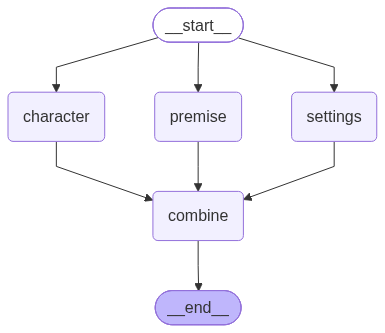

In [4]:
graph = StateGraph(State)

graph.add_node("character",generate_characters)
graph.add_node("settings",generate_settings)
graph.add_node("premise",generate_premise)
graph.add_node("combine", combine_elements)

graph.add_edge(START, "character")
graph.add_edge(START,"settings")
graph.add_edge(START,"premise")
graph.add_edge("character","combine")
graph.add_edge("settings","combine")
graph.add_edge("premise","combine")
graph.add_edge("combine",END)

build = graph.compile()

graph_img = build.get_graph().draw_mermaid_png()
display(Image(graph_img))

In [6]:
state = {"topic":"Artificial Systems"}
result = build.invoke(state)
print(result["story_intro"])

Beneath a bruised violet sky, the metropolis of Veyron sprawled like a living organism—an endless lattice of steel, glass, and circuitry. Every building was a cathedral to computation, its façades a tapestry of shifting holographic murals that pulsed in sync with the city’s neural network. The streets hummed with a low, resonant bass that was the collective heartbeat of millions of processors, each one a neuron in the urban brain. The air was thin, tinged with the sharp scent of ozone and burnt copper, a reminder that the city breathed electric fire.

At the heart of Veyron lay the Central Synapse, a monolithic data center that dominated the skyline. Its outer shell was a lattice of titanium ribs and translucent panels, through which streams of neon blue, amber, and violet cascaded like auroras. Inside, rows upon rows of server racks thrum with a steady, almost hypnotic rhythm. The servers were not mere machines; they were polished, chrome‑capped orbs that glowed with a soft, biolumine